In [1]:
# Adding all of data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle


airlines_df = pd.read_csv('airlines.csv')
airports_df = pd.read_csv('airports.csv')
flights_df  = pd.read_csv('flights.csv')

print("flights_df:", flights_df.shape)
print("airlines_df:", airlines_df.shape)
print("airports_df:", airports_df.shape)

C:\Users\meisn\AppData\Local\Temp\ipykernel_10284\1310780370.py:12: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  flights_df  = pd.read_csv('flights.csv')


flights_df: (5819079, 31)
airlines_df: (14, 2)
airports_df: (322, 7)


### Starting with removing features and missing values 

In [2]:
missing = (flights_df.isnull().sum().sort_values(ascending=False))
missing = missing[missing > 0]
missing

CANCELLATION_REASON    5729195
WEATHER_DELAY          4755640
LATE_AIRCRAFT_DELAY    4755640
AIRLINE_DELAY          4755640
SECURITY_DELAY         4755640
AIR_SYSTEM_DELAY       4755640
AIR_TIME                105071
ARRIVAL_DELAY           105071
ELAPSED_TIME            105071
WHEELS_ON                92513
TAXI_IN                  92513
ARRIVAL_TIME             92513
TAXI_OUT                 89047
WHEELS_OFF               89047
DEPARTURE_DELAY          86153
DEPARTURE_TIME           86153
TAIL_NUMBER              14721
SCHEDULED_TIME               6
dtype: int64

In [3]:
# Columns with < 5% missing — safe to fill with median
flights_df['DEPARTURE_DELAY'] = flights_df['DEPARTURE_DELAY'].fillna(flights_df['DEPARTURE_DELAY'].median())
flights_df['TAXI_OUT']        = flights_df['TAXI_OUT'].fillna(flights_df['TAXI_OUT'].median())
flights_df['DEPARTURE_TIME']  = flights_df['DEPARTURE_TIME'].fillna(flights_df['DEPARTURE_TIME'].median())
# Delay cause columns: NaN means delay did not occur, fill with 0
for col in ['AIR_SYSTEM_DELAY','WEATHER_DELAY','LATE_AIRCRAFT_DELAY','AIRLINE_DELAY','SECURITY_DELAY']:flights_df[col] = flights_df[col].fillna(0)
# SCHEDULED_TIME: fill with mode (categorical-style distribution)
flights_df['SCHEDULED_TIME'] = flights_df['SCHEDULED_TIME'].fillna(flights_df['SCHEDULED_TIME'].mode()[0])
# Drop columns with > 30% missing or post-event leakage
drop_cols = ['ARRIVAL_DELAY','AIR_TIME','TAXI_IN','WHEELS_ON','ELAPSED_TIME','CANCELLATION_REASON','TAIL_NUMBER','ARRIVAL_TIME','WHEELS_OFF','YEAR','CANCELLED','DIVERTED']
flights_df = flights_df.drop(columns=drop_cols, errors='ignore')
# Clean and validate airport codes (must be 3 uppercase letters)
flights_df['ORIGIN_AIRPORT']      = flights_df['ORIGIN_AIRPORT'].astype(str).str.strip()
flights_df['DESTINATION_AIRPORT'] = flights_df['DESTINATION_AIRPORT'].astype(str).str.strip()
valid_iata = r'^[A-Z]{3}$'
flights_df = flights_df[flights_df['ORIGIN_AIRPORT'].str.match(valid_iata) & flights_df['DESTINATION_AIRPORT'].str.match(valid_iata)].copy()
print("Cleaned shape:", flights_df.shape)

Cleaned shape: (5332914, 19)


In [4]:
flights_df.isnull().sum().sort_values(ascending=False)

MONTH                  0
TAXI_OUT               0
LATE_AIRCRAFT_DELAY    0
AIRLINE_DELAY          0
SECURITY_DELAY         0
AIR_SYSTEM_DELAY       0
SCHEDULED_ARRIVAL      0
DISTANCE               0
SCHEDULED_TIME         0
DEPARTURE_DELAY        0
DAY                    0
DEPARTURE_TIME         0
SCHEDULED_DEPARTURE    0
DESTINATION_AIRPORT    0
ORIGIN_AIRPORT         0
FLIGHT_NUMBER          0
AIRLINE                0
DAY_OF_WEEK            0
WEATHER_DELAY          0
dtype: int64

In [ ]:
summary = {'Metric': ['Original rows','Rows after airport code filter', 'Columns — original','Columns — after drop','Missing values remaining', 'Duplicate rows'],
    'Value': [5_819_079,flights_df.shape[0], 32, flights_df.shape[1],flights_df.isnull().sum().sum(),flights_df.duplicated().sum()]}
pd.DataFrame(summary).set_index('Metric')

,Value
Metric,
Original rows,5819079
Rows after airport code filter,5332914
Columns — original,32
Columns — after drop,19
Missing values remaining,0
Duplicate rows,0


In [6]:
# FAA defines a delayed flight as departing 15+ minutes after scheduled time
flights_df['DELAY_RISK'] = (flights_df['DEPARTURE_DELAY'] > 15).astype(int)
print("Target distribution:")
print(flights_df['DELAY_RISK'].value_counts())
print()
print(f"Delay rate: {flights_df['DELAY_RISK'].mean()*100:.1f}%")

Target distribution:
DELAY_RISK
0    4372091
1     960823
Name: count, dtype: int64

Delay rate: 18.0%


In [7]:
print("Duplicate rows:", flights_df.duplicated().sum())

Duplicate rows: 0


In [8]:
flights_df.dtypes

MONTH                    int64
DAY                      int64
DAY_OF_WEEK              int64
AIRLINE                 object
FLIGHT_NUMBER            int64
ORIGIN_AIRPORT          object
DESTINATION_AIRPORT     object
SCHEDULED_DEPARTURE      int64
DEPARTURE_TIME         float64
DEPARTURE_DELAY        float64
TAXI_OUT               float64
SCHEDULED_TIME         float64
DISTANCE                 int64
SCHEDULED_ARRIVAL        int64
AIR_SYSTEM_DELAY       float64
SECURITY_DELAY         float64
AIRLINE_DELAY          float64
LATE_AIRCRAFT_DELAY    float64
WEATHER_DELAY          float64
DELAY_RISK               int64
dtype: object

In [9]:
print(flights_df["DELAY_RISK"].value_counts())

DELAY_RISK
0    4372091
1     960823
Name: count, dtype: int64


In [10]:
flights_df.describe()

,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,SCHEDULED_TIME,DISTANCE,SCHEDULED_ARRIVAL,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,DELAY_RISK
count,5.332914e+06,5.332914e+06,5.332914e+06,5.332914e+06,5.332914e+06,5.332914e+06,5.332914e+06,5.332914e+06,5.332914e+06,5.332914e+06,5.332914e+06,5.332914e+06,5.332914e+06,5.332914e+06,5.332914e+06,5.332914e+06,5.332914e+06
mean,6.207210e+00,1.568874e+01,3.919179e+00,2.178419e+03,1.330107e+03,1.335978e+03,9.589514e+00,1.606874e+01,1.417831e+02,8.228955e+02,1.493747e+03,2.537649e+00,1.461584e-02,3.556582e+00,4.456789e+00,5.608581e-01,1.801685e-01
std,3.383807e+00,8.774687e+00,1.993635e+00,1.760521e+03,4.843130e+02,4.934878e+02,3.732450e+01,8.921759e+00,7.525169e+01,6.077992e+02,5.079263e+02,1.326864e+01,9.460972e-01,2.203969e+01,2.094994e+01,9.019633e+00,3.843278e-01
min,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.200000e+01,1.000000e+00,1.800000e+01,2.100000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.000000e+00,8.000000e+00,2.000000e+00,7.310000e+02,9.170000e+02,9.250000e+02,-5.000000e+00,1.100000e+01,8.500000e+01,3.730000e+02,1.110000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.000000e+00,1.600000e+01,4.000000e+00,1.690000e+03,1.325000e+03,1.330000e+03,-2.000000e+00,1.400000e+01,1.230000e+02,6.490000e+02,1.520000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,9.000000e+00,2.300000e+01,6.000000e+00,3.252000e+03,1.730000e+03,1.737000e+03,7.000000e+00,1.900000e+01,1.740000e+02,1.065000e+03,1.919000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,1.200000e+01,3.100000e+01,7.000000e+00,9.855000e+03,2.359000e+03,2.400000e+03,1.988000e+03,2.250000e+02,7.180000e+02,4.983000e+03,2.400000e+03,1.134000e+03,5.730000e+02,1.971000e+03,1.331000e+03,1.211000e+03,1.000000e+00


In [11]:
flights_df["DEPARTURE_TIME"].describe()

count    5.332914e+06
mean     1.335978e+03
std      4.934878e+02
min      1.000000e+00
25%      9.250000e+02
50%      1.330000e+03
75%      1.737000e+03
max      2.400000e+03
Name: DEPARTURE_TIME, dtype: float64

In [12]:
# Cleaning a bit more
flights_df = flights_df.drop(columns=['YEAR','CANCELLED','DIVERTED'], errors="ignore")
flights_df.head()

,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,SCHEDULED_TIME,DISTANCE,SCHEDULED_ARRIVAL,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,DELAY_RISK
0,1,1,4,AS,98,ANC,SEA,5,2354.0,-11.0,21.0,205.0,1448,430,0.0,0.0,0.0,0.0,0.0,0
1,1,1,4,AA,2336,LAX,PBI,10,2.0,-8.0,12.0,280.0,2330,750,0.0,0.0,0.0,0.0,0.0,0
2,1,1,4,US,840,SFO,CLT,20,18.0,-2.0,16.0,286.0,2296,806,0.0,0.0,0.0,0.0,0.0,0
3,1,1,4,AA,258,LAX,MIA,20,15.0,-5.0,15.0,285.0,2342,805,0.0,0.0,0.0,0.0,0.0,0
4,1,1,4,AS,135,SEA,ANC,25,24.0,-1.0,11.0,235.0,1448,320,0.0,0.0,0.0,0.0,0.0,0


In [13]:
flights_df["DEPARTURE_TIME"].describe()

count    5.332914e+06
mean     1.335978e+03
std      4.934878e+02
min      1.000000e+00
25%      9.250000e+02
50%      1.330000e+03
75%      1.737000e+03
max      2.400000e+03
Name: DEPARTURE_TIME, dtype: float64

### Feature Engineering

In [14]:
# IS_PEAK_HOUR: morning rush 07:00–10:00, highest congestion window
flights_df['IS_PEAK_HOUR'] = (
    flights_df['SCHEDULED_DEPARTURE'].between(700, 1000)).astype(int)

# IS_WEEKEND: Saturday=6, Sunday=7 in this dataset
flights_df['IS_WEEKEND'] = (
    flights_df['DAY_OF_WEEK'].isin([6, 7])).astype(int)

# IS_LATE_NIGHT: departures after 21:00 — delay accumulation effect
flights_df['IS_LATE_NIGHT'] = (
    flights_df['SCHEDULED_DEPARTURE'] >= 2100).astype(int)

# IS_LONG_HAUL: > 1500 miles — higher operational complexity
flights_df['IS_LONG_HAUL'] = (
    flights_df['DISTANCE'] > 1500).astype(int)

# EARLY_MORNING_FLIGHT: before 06:00 — typically lowest delay risk
flights_df['EARLY_MORNING_FLIGHT'] = (
    flights_df['SCHEDULED_DEPARTURE'] <= 600).astype(int)

# IS_MAJOR_HUB: top 6 US hubs by traffic volume
major_airports = ['ATL','ORD','DFW','DEN','LAX','JFK']
flights_df['IS_MAJOR_HUB'] = (
    flights_df['ORIGIN_AIRPORT'].isin(major_airports)).astype(int)

# ROUTE: keep as reference, will be dropped before encoding
flights_df['ROUTE'] = (
    flights_df['ORIGIN_AIRPORT'] + '_' + flights_df['DESTINATION_AIRPORT'])

# SEASON: meteorological seasons for weather-driven delay patterns
def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    if month in [3, 4, 5]:  return 'Spring'
    if month in [6, 7, 8]:  return 'Summer'
    return 'Autumn'

flights_df['SEASON'] = flights_df['MONTH'].apply(get_season)

print("New features added. Shape:", flights_df.shape)

New features added. Shape: (5332914, 28)


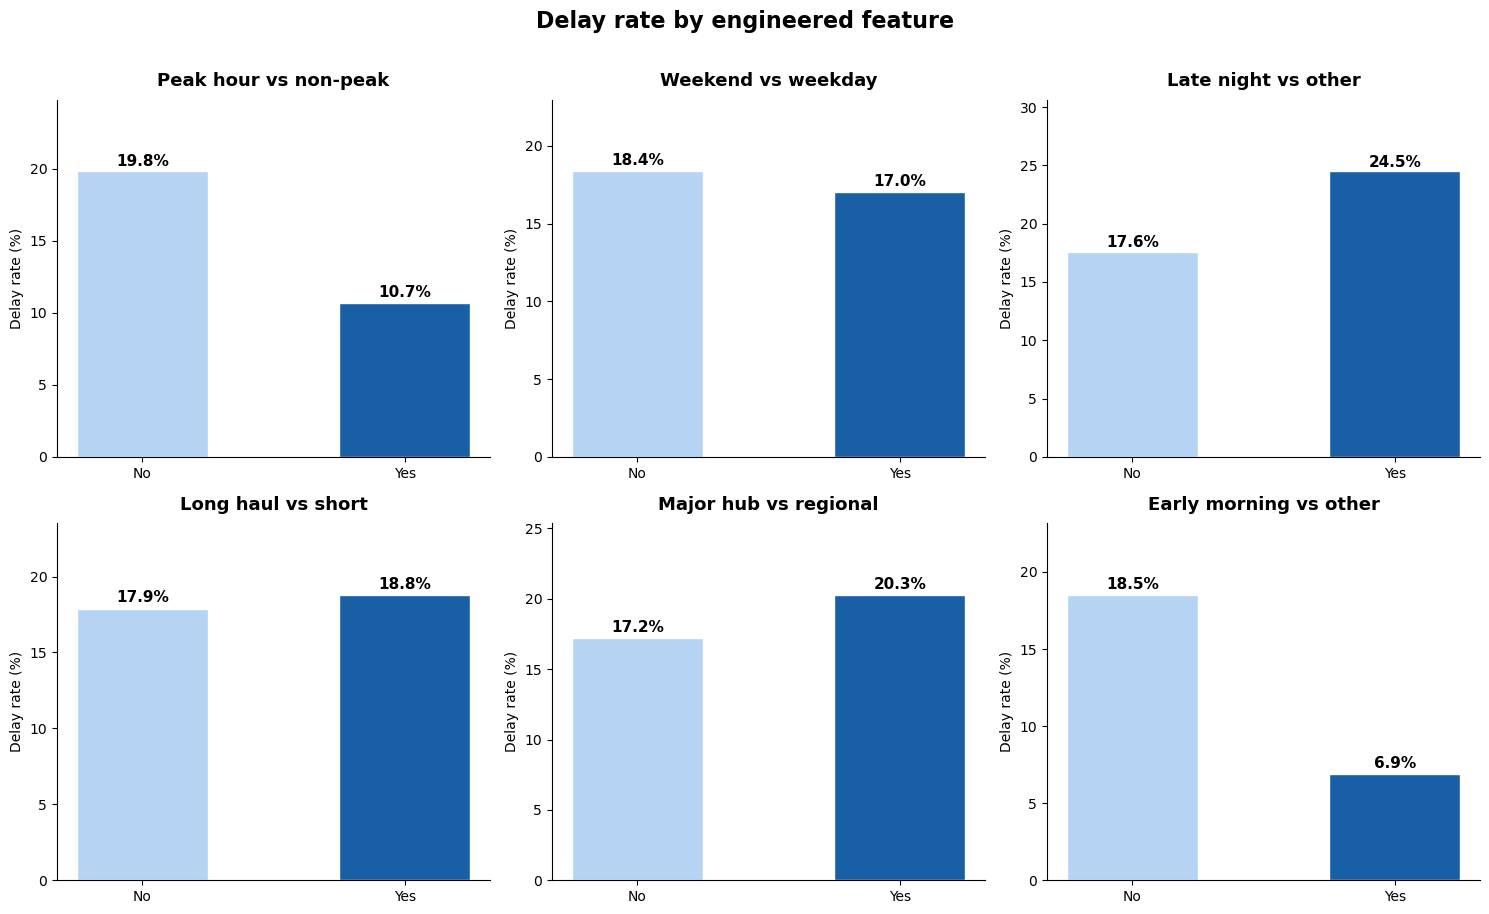

In [15]:
binary_features = [
    ('IS_PEAK_HOUR',        'Peak hour vs non-peak'),
    ('IS_WEEKEND',          'Weekend vs weekday'),
    ('IS_LATE_NIGHT',       'Late night vs other'),
    ('IS_LONG_HAUL',        'Long haul vs short'),
    ('IS_MAJOR_HUB',        'Major hub vs regional'),
    ('EARLY_MORNING_FLIGHT','Early morning vs other'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (feat, label) in enumerate(binary_features):
    delay_rates = (
        flights_df.groupby(feat)['DELAY_RISK']
        .mean() * 100
    )
    bars = axes[i].bar(
        ['No', 'Yes'],
        delay_rates.values,
        color=['#B5D4F4','#185FA5'],
        edgecolor='white',
        width=0.5
    )
    for bar, val in zip(bars, delay_rates.values):
        axes[i].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.4,
            f'{val:.1f}%',
            ha='center', fontsize=11, fontweight='bold'
        )
    axes[i].set_title(label, fontsize=13, fontweight='bold', pad=10)
    axes[i].set_ylabel('Delay rate (%)', fontsize=10)
    axes[i].set_ylim(0, delay_rates.max() * 1.25)
    axes[i].spines[['top','right']].set_visible(False)

plt.suptitle('Delay rate by engineered feature',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

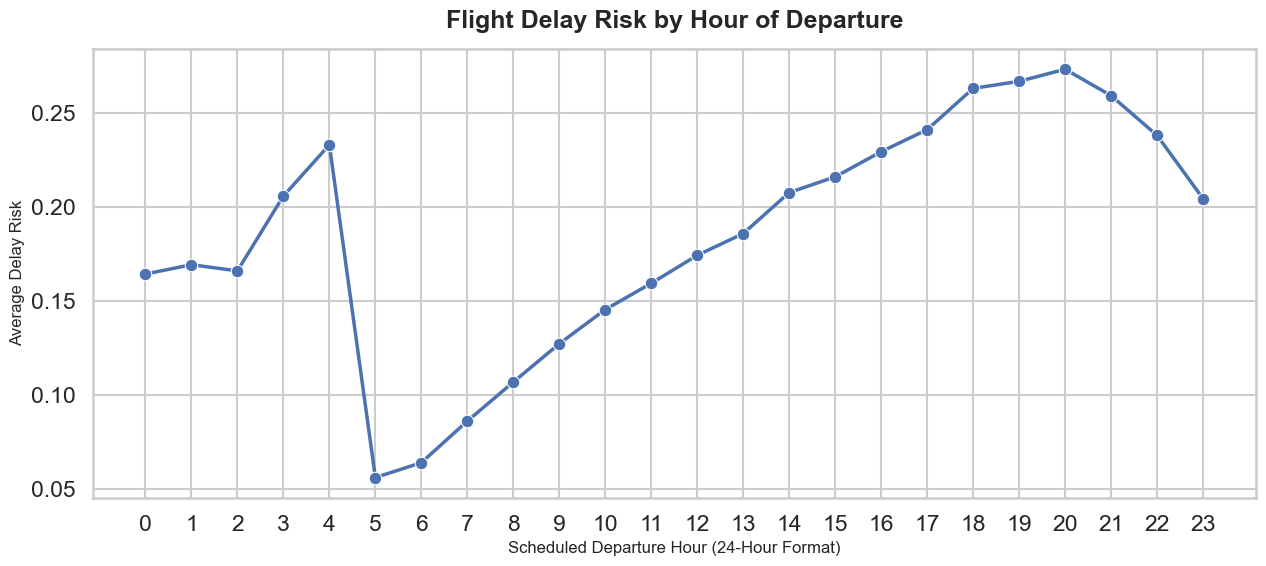

In [16]:
# Convert scheduled departure to hour of day
flights_df['DEPARTURE_HOUR'] = (flights_df['SCHEDULED_DEPARTURE'] // 100)

# Keep only valid hours
flights_df = flights_df[flights_df['DEPARTURE_HOUR'].between(0, 23)]
delay_by_hour = (flights_df.groupby("DEPARTURE_HOUR")["DELAY_RISK"].mean() .reset_index())
sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(13, 6))
sns.lineplot(data=delay_by_hour,x='DEPARTURE_HOUR',y='DELAY_RISK',marker="o",linewidth=2.5)
plt.title('Flight Delay Risk by Hour of Departure',fontsize=18,fontweight="bold",pad=15)
plt.xlabel("Scheduled Departure Hour (24-Hour Format)", fontsize=12)
plt.ylabel( "Average Delay Risk", fontsize=12)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

## Insight

Delay risk increases during specific operational windows, particularly during peak daytime and late evening departures. This suggests that airport congestion, crew scheduling pressure, and accumulated operational delays throughout the day significantly impact departure reliability.

This insight supports proactive scheduling decisions and targeted operational planning during high-risk departure windows.

In [ ]:
feature_summary = pd.DataFrame({
    'Feature': [
        'IS_PEAK_HOUR',
        'IS_WEEKEND',
        'IS_LATE_NIGHT',
        'IS_LONG_HAUL',
        'EARLY_MORNING_FLIGHT',
        'IS_MAJOR_HUB',
        'SEASON'
    ],
    'Logic': [
        'SCHEDULED_DEPARTURE between 700–1000',
        'DAY_OF_WEEK in [6, 7]',
        'SCHEDULED_DEPARTURE >= 2100',
        'DISTANCE > 1500 miles',
        'SCHEDULED_DEPARTURE <= 600',
        'ORIGIN_AIRPORT in top 6 hubs',
        'MONTH grouped into 4 seasons'
    ],
    'Business rationale': [
        'Morning rush = peak airport congestion',
        'Leisure demand surge on weekends',
        'Cascading delay accumulation by day-end',
        'Greater complexity, more disruption exposure',
        'Early flights have cleanest operational slate',
        'High-traffic hubs have more systemic risk',
        'Weather and demand vary significantly by season'
    ],
    'Type': ['Binary','Binary','Binary','Binary','Binary','Binary','Categorical']
})

feature_summary.set_index('Feature')

,Logic,Business rationale,Type
Feature,,,
IS_PEAK_HOUR,SCHEDULED_DEPARTURE between 700–1000,Morning rush = peak airport congestion,Binary
IS_WEEKEND,"DAY_OF_WEEK in [6, 7]",Leisure demand surge on weekends,Binary
IS_LATE_NIGHT,SCHEDULED_DEPARTURE >= 2100,Cascading delay accumulation by day-end,Binary
IS_LONG_HAUL,DISTANCE > 1500 miles,"Greater complexity, more disruption exposure",Binary
EARLY_MORNING_FLIGHT,SCHEDULED_DEPARTURE <= 600,Early flights have cleanest operational slate,Binary
IS_MAJOR_HUB,ORIGIN_AIRPORT in top 6 hubs,High-traffic hubs have more systemic risk,Binary
SEASON,MONTH grouped into 4 seasons,Weather and demand vary significantly by season,Categorical


In [18]:
flights_df.head(20)

,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,...,DELAY_RISK,IS_PEAK_HOUR,IS_WEEKEND,IS_LATE_NIGHT,IS_LONG_HAUL,EARLY_MORNING_FLIGHT,IS_MAJOR_HUB,ROUTE,SEASON,DEPARTURE_HOUR
0,1,1,4,AS,98,ANC,SEA,5,2354.0,-11.0,...,0,0,0,0,0,1,0,ANC_SEA,Winter,0
1,1,1,4,AA,2336,LAX,PBI,10,2.0,-8.0,...,0,0,0,0,1,1,1,LAX_PBI,Winter,0
2,1,1,4,US,840,SFO,CLT,20,18.0,-2.0,...,0,0,0,0,1,1,0,SFO_CLT,Winter,0
3,1,1,4,AA,258,LAX,MIA,20,15.0,-5.0,...,0,0,0,0,1,1,1,LAX_MIA,Winter,0
4,1,1,4,AS,135,SEA,ANC,25,24.0,-1.0,...,0,0,0,0,0,1,0,SEA_ANC,Winter,0
5,1,1,4,DL,806,SFO,MSP,25,20.0,-5.0,...,0,0,0,0,1,1,0,SFO_MSP,Winter,0
6,1,1,4,NK,612,LAS,MSP,25,19.0,-6.0,...,0,0,0,0,0,1,0,LAS_MSP,Winter,0
7,1,1,4,US,2013,LAX,CLT,30,44.0,14.0,...,0,0,0,0,1,1,1,LAX_CLT,Winter,0
8,1,1,4,AA,1112,SFO,DFW,30,19.0,-11.0,...,0,0,0,0,0,1,0,SFO_DFW,Winter,0
9,1,1,4,DL,1173,LAS,ATL,30,33.0,3.0,...,0,0,0,0,1,1,0,LAS_ATL,Winter,0


In [19]:
flights_df.columns

Index(['MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE',
       'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'SCHEDULED_TIME',
       'DISTANCE', 'SCHEDULED_ARRIVAL', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY',
       'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY', 'DELAY_RISK',
       'IS_PEAK_HOUR', 'IS_WEEKEND', 'IS_LATE_NIGHT', 'IS_LONG_HAUL',
       'EARLY_MORNING_FLIGHT', 'IS_MAJOR_HUB', 'ROUTE', 'SEASON',
       'DEPARTURE_HOUR'],
      dtype='object')

In [20]:
flights_df[["ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "ROUTE"]].head()

,ORIGIN_AIRPORT,DESTINATION_AIRPORT,ROUTE
0,ANC,SEA,ANC_SEA
1,LAX,PBI,LAX_PBI
2,SFO,CLT,SFO_CLT
3,LAX,MIA,LAX_MIA
4,SEA,ANC,SEA_ANC


#### Feature Engineering Strategy

Features were engineered using operational logic and business understanding rather than arbitrary transformations.

The goal was to improve prediction of departure delay risk before flight departure by capturing:

- Airport congestion risk
- Seasonal delay patterns
- Route level operational complexity
- Main peak hour schedulling pressure
- The late night delay accumulation
- Major hub airport behavior


### Encoding and Model Prep

In [21]:
flights_df.dtypes

MONTH                     int64
DAY                       int64
DAY_OF_WEEK               int64
AIRLINE                  object
FLIGHT_NUMBER             int64
ORIGIN_AIRPORT           object
DESTINATION_AIRPORT      object
SCHEDULED_DEPARTURE       int64
DEPARTURE_TIME          float64
DEPARTURE_DELAY         float64
TAXI_OUT                float64
SCHEDULED_TIME          float64
DISTANCE                  int64
SCHEDULED_ARRIVAL         int64
AIR_SYSTEM_DELAY        float64
SECURITY_DELAY          float64
AIRLINE_DELAY           float64
LATE_AIRCRAFT_DELAY     float64
WEATHER_DELAY           float64
DELAY_RISK                int64
IS_PEAK_HOUR              int64
IS_WEEKEND                int64
IS_LATE_NIGHT             int64
IS_LONG_HAUL              int64
EARLY_MORNING_FLIGHT      int64
IS_MAJOR_HUB              int64
ROUTE                    object
SEASON                   object
DEPARTURE_HOUR            int64
dtype: object

In [22]:
# What stays and what goes
# Drop
drop_cols = ['FLIGHT_NUMBER','ROUTE','ORIGIN_AIRPORT','DESTINATION_AIRPORT','DEPARTURE_DELAY']
model_df = flights_df.drop(columns=drop_cols, errors="ignore")
# Cat col
cat_col = ['AIRLINE', 'SEASON']
model_df = pd.get_dummies(model_df, columns=cat_col,drop_first=True)

print(model_df.shape)
model_df.head()

(5332914, 38)


,MONTH,DAY,DAY_OF_WEEK,SCHEDULED_DEPARTURE,DEPARTURE_TIME,TAXI_OUT,SCHEDULED_TIME,DISTANCE,SCHEDULED_ARRIVAL,AIR_SYSTEM_DELAY,...,AIRLINE_MQ,AIRLINE_NK,AIRLINE_OO,AIRLINE_UA,AIRLINE_US,AIRLINE_VX,AIRLINE_WN,SEASON_Spring,SEASON_Summer,SEASON_Winter
0,1,1,4,5,2354.0,21.0,205.0,1448,430,0.0,...,False,False,False,False,False,False,False,False,False,True
1,1,1,4,10,2.0,12.0,280.0,2330,750,0.0,...,False,False,False,False,False,False,False,False,False,True
2,1,1,4,20,18.0,16.0,286.0,2296,806,0.0,...,False,False,False,False,True,False,False,False,False,True
3,1,1,4,20,15.0,15.0,285.0,2342,805,0.0,...,False,False,False,False,False,False,False,False,False,True
4,1,1,4,25,24.0,11.0,235.0,1448,320,0.0,...,False,False,False,False,False,False,False,False,False,True


In [23]:
from sklearn.model_selection import train_test_split

X = model_df.drop(columns=['DELAY_RISK'])
y = model_df['DELAY_RISK']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Train size : {X_train.shape[0]:,} rows ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test size  : {X_test.shape[0]:,} rows ({len(X_test)/len(X)*100:.0f}%)")
print(f"Train delay rate: {y_train.mean()*100:.1f}%")
print(f"Test delay rate : {y_test.mean()*100:.1f}%  (stratify check)")

Train size : 4,266,331 rows (80%)
Test size  : 1,066,583 rows (20%)
Train delay rate: 18.0%
Test delay rate : 18.0%  (stratify check)


In [24]:
print(X.dtypes)

MONTH                     int64
DAY                       int64
DAY_OF_WEEK               int64
SCHEDULED_DEPARTURE       int64
DEPARTURE_TIME          float64
TAXI_OUT                float64
SCHEDULED_TIME          float64
DISTANCE                  int64
SCHEDULED_ARRIVAL         int64
AIR_SYSTEM_DELAY        float64
SECURITY_DELAY          float64
AIRLINE_DELAY           float64
LATE_AIRCRAFT_DELAY     float64
WEATHER_DELAY           float64
IS_PEAK_HOUR              int64
IS_WEEKEND                int64
IS_LATE_NIGHT             int64
IS_LONG_HAUL              int64
EARLY_MORNING_FLIGHT      int64
IS_MAJOR_HUB              int64
DEPARTURE_HOUR            int64
AIRLINE_AS                 bool
AIRLINE_B6                 bool
AIRLINE_DL                 bool
AIRLINE_EV                 bool
AIRLINE_F9                 bool
AIRLINE_HA                 bool
AIRLINE_MQ                 bool
AIRLINE_NK                 bool
AIRLINE_OO                 bool
AIRLINE_UA                 bool
AIRLINE_

In [25]:
# Save model-ready dataframe
model_df.to_csv('flight_delay_model_ready.csv', index=False)

# Save train/test splits so NB4 loads them directly
import pickle
with open('train_test_split.pkl', 'wb') as f:
    pickle.dump((X_train, X_test, y_train, y_test), f)

print("Saved:")
print(f"  flight_delay_model_ready.csv  ({os.path.getsize('flight_delay_model_ready.csv')/1e6:.1f} MB)")
print(f"  train_test_split.pkl")

Saved:


NameError: name 'os' is not defined